<a href="https://colab.research.google.com/github/maikej910-del/notebooks-Grupo_45/blob/main/Tech_Fase_4_Grupo_45.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Fase 4: Modelo Preditivo para Diagnóstico de Obesidade

**Contexto de Negócio:** Desenvolvimento de um pipeline de Machine Learning de ponta a ponta para classificar e prever o risco de obesidade de pacientes. O objetivo é fornecer uma ferramenta de suporte à decisão clínica e analítica para a equipe médica e diretoria do hospital.

## 1. Configuração do Ambiente e Ingestão de Dados
Estabelecimento das dependências estruturais e ingestão da base de dados bruta diretamente do repositório remoto. Essa abordagem *code-first* elimina a necessidade de uploads manuais, garantindo a reprodutibilidade do experimento em qualquer ambiente.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo padronizado para as visualizações
sns.set_theme(style="whitegrid", palette="muted")

# URL Raw do arquivo no GitHub
# Lembrete: confirme se a branch principal do seu repositório se chama 'main' ou 'master'
url_github = 'https://raw.githubusercontent.com/maikej910-del/notebooks-Grupo_45/main/Obesity.csv'

# Carregamento do dataset direto do repositório
df = pd.read_csv(url_github, sep=',', encoding='latin1')

# Verificação inicial da estrutura dos dados
display(df.head())

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Pipeline de ETL e Feature Engineering
Em vez de realizar tratamentos prévios em planilhas externas, estruturamos um pipeline automatizado de sanitização e padronização direto no código. As decisões técnicas desta etapa incluem:

1. **Mapeamento via Dicionário de Dados:** Tradução de features categóricas e conversão de escalas numéricas em representações literais (ex: converter o *score* 2 de consumo de água para '1-2 L/dia'). Essa transformação é fundamental para a explicabilidade do modelo e para garantir que o futuro Dashboard Analítico seja intuitivo para a equipe médica, sem a necessidade de tabelas "de-para".
2. **Sanitização de Ruídos:** Remoção de anomalias decimais nas variáveis ordinais discretas, corrigindo inconsistências na coleta de dados mapeadas pelo edital.
3. **Feature Engineering (Injeção de Conhecimento de Domínio):** A obesidade é clinicamente pautada no Índice de Massa Corporal (Peso/Altura²). A criação explícita da variável `IMC` reduz o esforço computacional dos algoritmos na busca por essa relação não-linear, acelerando a convergência e elevando o poder preditivo da máquina.

In [7]:
# ==============================================================================
# 2. PIPELINE DE PRÉ-PROCESSAMENTO E FEATURE ENGINEERING
# Automatização da limpeza e padronização dos dados para garantir reprodutibilidade.
# ==============================================================================

# 2.1. Padronização das Features (Tradução para o contexto de negócio local)
traducao_colunas = {
    'Gender': 'Genero',
    'Age': 'Idade',
    'Height': 'Altura',
    'Weight': 'Peso',
    'family_history': 'Historico_Familiar',
    'FAVC': 'Consumo_Alta_Caloria',
    'FCVC': 'Consumo_Vegetais',
    'NCP': 'Refeicoes_Dia',
    'CAEC': 'Consumo_Entre_Refeicoes',
    'SMOKE': 'Fumante',
    'CH2O': 'Consumo_Agua',
    'SCC': 'Monitora_Calorias',
    'FAF': 'Frequencia_Ativ_Fisica',
    'TUE': 'Tempo_Telas',
    'CALC': 'Consumo_Alcool',
    'MTRANS': 'Meio_Transporte',
    'Obesity': 'Classe_Peso',
    'Obesity_level': 'Classe_Peso',
    'NObeyesdad': 'Classe_Peso'
}
df.rename(columns=traducao_colunas, inplace=True)

# 2.2. Mapeamento de Variáveis Categóricas Nominais
traducao_valores = {
    'yes': 'Sim',
    'no': 'Nao',
    'Female': 'Feminino',
    'Male': 'Masculino',
    'Sometimes': 'As vezes',
    'Frequently': 'Frequentemente',
    'Always': 'Sempre',
    'Automobile': 'Carro',
    'Motorbike': 'Moto',
    'Bike': 'Bicicleta',
    'Public_Transportation': 'Transporte Publico',
    'Walking': 'A pe',
    'Insufficient_Weight': 'Abaixo do peso',
    'Normal_Weight': 'Peso normal',
    'Overweight_Level_I': 'Sobrepeso I',
    'Overweight_Level_II': 'Sobrepeso II',
    'Obesity_Type_I': 'Obesidade I',
    'Obesity_Type_II': 'Obesidade II',
    'Obesity_Type_III': 'Obesidade III'
}

colunas_texto = df.select_dtypes(include="object").columns
for col in colunas_texto:
    df[col] = df[col].astype(str).str.replace("–", "-", regex=False)
    df[col] = df[col].map(traducao_valores).fillna(df[col])

# 2.3. Tratamento de ruídos e Mapeamento de Variáveis Ordinais (Escalas)
# Primeiro arredondamos os decimais ruidosos para o inteiro mais próximo
colunas_escala = ['Consumo_Vegetais', 'Refeicoes_Dia', 'Consumo_Agua', 'Frequencia_Ativ_Fisica', 'Tempo_Telas']
for col in colunas_escala:
    df[col] = df[col].round().astype(int)

# Aplicando as descrições literais baseadas no dicionário de dados
df['Consumo_Vegetais'] = df['Consumo_Vegetais'].map({1: 'Raramente', 2: 'As vezes', 3: 'Sempre'})
df['Refeicoes_Dia'] = df['Refeicoes_Dia'].map({1: '1 refeicao', 2: '2 refeicoes', 3: '3 refeicoes', 4: '4 ou mais'})
df['Consumo_Agua'] = df['Consumo_Agua'].map({1: '< 1 L/dia', 2: '1-2 L/dia', 3: '> 2 L/dia'})
df['Frequencia_Ativ_Fisica'] = df['Frequencia_Ativ_Fisica'].map({0: 'Nenhuma', 1: '1-2 dias/sem', 2: '3-4 dias/sem', 3: '5+ dias/sem'})
df['Tempo_Telas'] = df['Tempo_Telas'].map({0: '0-2 h/dia', 1: '3-5 h/dia', 2: '> 5 h/dia'})

# 2.4. Conversão de Tipagem (Ajuste de separador decimal)
if df["Altura"].dtype == 'O':
    df["Altura"] = df["Altura"].astype(str).str.replace(",", ".").astype(float)
if df["Peso"].dtype == 'O':
    df["Peso"] = df["Peso"].astype(str).str.replace(",", ".").astype(float)

# 2.5. Feature Engineering (Cálculo do IMC baseado no domínio do negócio)
df["IMC"] = round(df["Peso"] / (df["Altura"] ** 2), 2)

print("Pipeline executado: Dados padronizados, escalas traduzidas e feature IMC criada com sucesso.\n")
display(df.head())

Pipeline executado: Dados padronizados, escalas traduzidas e feature IMC criada com sucesso.



,Genero,Idade,Altura,Peso,Historico_Familiar,Consumo_Alta_Caloria,Consumo_Vegetais,Refeicoes_Dia,Consumo_Entre_Refeicoes,Fumante,Consumo_Agua,Monitora_Calorias,Frequencia_Ativ_Fisica,Tempo_Telas,Consumo_Alcool,Meio_Transporte,Classe_Peso,IMC
0,Feminino,21.0,1.62,64.0,Sim,Nao,As vezes,3 refeicoes,As vezes,Nao,1-2 L/dia,Nao,Nenhuma,3-5 h/dia,Nao,Transporte Publico,Peso normal,24.39
1,Feminino,21.0,1.52,56.0,Sim,Nao,Sempre,3 refeicoes,As vezes,Sim,> 2 L/dia,Sim,5+ dias/sem,0-2 h/dia,As vezes,Transporte Publico,Peso normal,24.24
2,Masculino,23.0,1.80,77.0,Sim,Nao,As vezes,3 refeicoes,As vezes,Nao,1-2 L/dia,Nao,3-4 dias/sem,3-5 h/dia,Frequentemente,Transporte Publico,Peso normal,23.77
3,Masculino,27.0,1.80,87.0,Nao,Nao,Sempre,3 refeicoes,As vezes,Nao,1-2 L/dia,Nao,3-4 dias/sem,0-2 h/dia,Frequentemente,A pe,Sobrepeso I,26.85
4,Masculino,22.0,1.78,89.8,Nao,Nao,As vezes,1 refeicao,As vezes,Nao,1-2 L/dia,Nao,Nenhuma,0-2 h/dia,As vezes,Transporte Publico,Sobrepeso II,28.34


## 3. Análise Exploratória de Dados (EDA)
Validação visual da distribuição dos dados, agora devidamente padronizados para a taxonomia do negócio local.

O primeiro gráfico atesta a coerência estatística da nossa nova *feature* de IMC contra os diagnósticos (Target) rotulados pela equipe médica. O segundo gráfico (Mapa de Calor de Pearson) investiga potenciais multicolinearidades entre as variáveis contínuas, garantindo que não existam correlações perfeitas que possam enviesar os pesos do modelo.

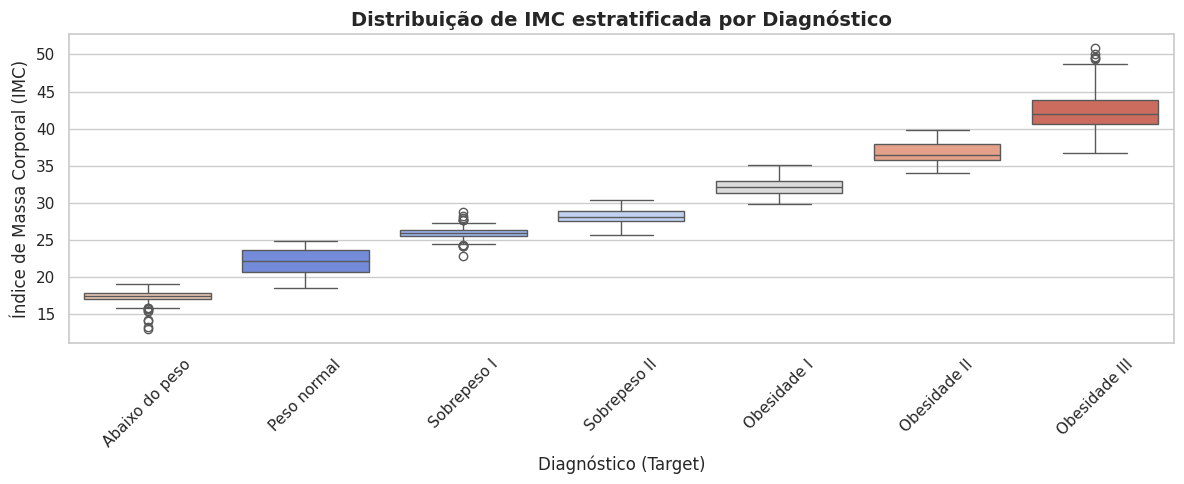

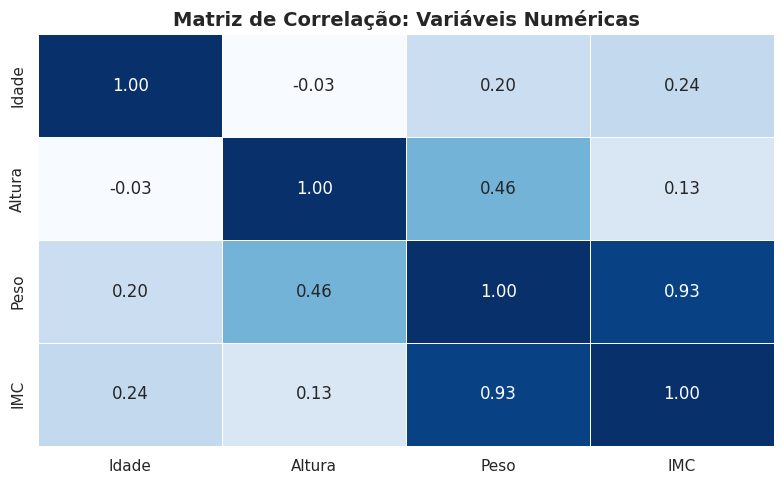

In [8]:
# ==============================================================================
# 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# Validação visual das features criadas e análise de multicolinearidade.
# ==============================================================================

# Gráfico 1: Validação do IMC vs. Classes de Peso
plt.figure(figsize=(12, 5))

# Definindo a ordem lógica da evolução clínica
ordem_classes = ['Abaixo do peso', 'Peso normal', 'Sobrepeso I', 'Sobrepeso II',
                 'Obesidade I', 'Obesidade II', 'Obesidade III']

sns.boxplot(
    data=df,
    x='Classe_Peso',
    y='IMC',
    order=ordem_classes,
    palette='coolwarm',
    hue='Classe_Peso',
    legend=False
)

plt.title('Distribuição de IMC estratificada por Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico (Target)', fontsize=12)
plt.ylabel('Índice de Massa Corporal (IMC)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2: Matriz de Correlação de Pearson
plt.figure(figsize=(8, 5))

# Isolando as numéricas para correlação
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
matriz_corr = df[num_cols].corr()

sns.heatmap(matriz_corr, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Matriz de Correlação: Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Estruturação do Pré-processador (Mitigação de Data Leakage)
Para garantir que o algoritmo generalize padrões reais e não apenas "decore" a base, encapsulamos as transformações matemáticas em um `Pipeline` via `ColumnTransformer`.

* **StandardScaler:** Aplicado às variáveis numéricas para padronização (z-score), evitando que *features* com grandezas desproporcionais (ex: Idade vs. Peso) dominem a função de custo do modelo.
* **OneHotEncoder:** Binarização das variáveis categóricas. Utilizamos o hiperparâmetro `drop='first'` para remover categorias redundantes, mitigando a multicolinearidade (conhecida como Armadilha das Variáveis Dummy).
* **Holdout Estratificado:** Divisão do dataset em 80% para treino e 20% para teste. O uso do parâmetro `stratify=y` garante que a proporção demográfica de cada classe de obesidade seja rigidamente mantida em ambos os conjuntos.

In [9]:
# ==============================================================================
# 4. ESTRUTURAÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO
# Divisão dos dados e criação das transformações (Scaling e Encoding)
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Isolando a variável resposta (Target) das variáveis explicativas (Features)
X = df.drop("Classe_Peso", axis=1)
y = df["Classe_Peso"]

# Identificando colunas numéricas e categóricas dinamicamente
numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Features Numéricas mapeadas: {len(numericas)}")
print(f"Features Categóricas mapeadas: {len(categoricas)}\n")

# Construindo o Pré-processador para evitar Data Leakage
preprocessador = ColumnTransformer(
    transformers=[
        # StandardScaler: Média 0, Desvio Padrão 1
        ("num", StandardScaler(), numericas),
        # OneHotEncoder: Transformando texto em números (drop='first' evita multicolinearidade)
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categoricas)
    ]
)

# Holdout de dados: 80% treino, 20% teste (stratify=y mantém a proporção das classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensões do conjunto de treino (X_train): {X_train.shape}")
print(f"Dimensões do conjunto de teste (X_test): {X_test.shape}")
print("\nPipeline de pré-processamento estruturado com sucesso!")

Features Numéricas mapeadas: 4
Features Categóricas mapeadas: 13

Dimensões do conjunto de treino (X_train): (1688, 17)
Dimensões do conjunto de teste (X_test): (423, 17)

Pipeline de pré-processamento estruturado com sucesso!


## 5. Modelagem Preditiva e Avaliação de Desempenho
Nesta etapa final do ambiente de experimentação, instanciamos o algoritmo de aprendizado de máquina e avaliamos sua capacidade de generalização.

* **Algoritmo Escolhido:** `RandomForestClassifier`. Trata-se de um modelo ensemble baseado em árvores de decisão, altamente robusto contra overfitting e excelente para capturar as relações não-lineares presentes em dados de saúde (como a relação entre histórico familiar, IMC e consumo calórico).
* **Hiperparâmetros:** Utilizamos `class_weight='balanced'` para garantir que o algoritmo dê a devida atenção a todas as classes, mitigando potenciais vieses causados por variações de volumetria entre as categorias do target.
* **Métricas de Negócio:** Além da acurácia global, plotamos a Matriz de Confusão. Esta visualização é crucial para a área médica, pois permite auditar a proporção de "falsos positivos" e "falsos negativos" em diagnósticos limítrofes (ex: transição de Sobrepeso para Obesidade).
* **Deploy e Exportação de Artefatos:** Além da serialização do estimador final (`.pkl`) e da base consolidada (`.csv`), automatizamos a geração de dois componentes críticos para o deploy na nuvem: o script da interface web (`app.py`), parametrizado para espelhar a dimensionalidade do pipeline (incluindo o cálculo estrutural do IMC no backend), e o arquivo de dependências (`requirements.txt`), que "trava" as versões exatas das bibliotecas utilizadas no treinamento, garantindo a reprodutibilidade do modelo no Streamlit Cloud sem erros de incompatibilidade.

Processando treinamento do modelo Random Forest...
ACURÁCIA GLOBAL: 98.58%


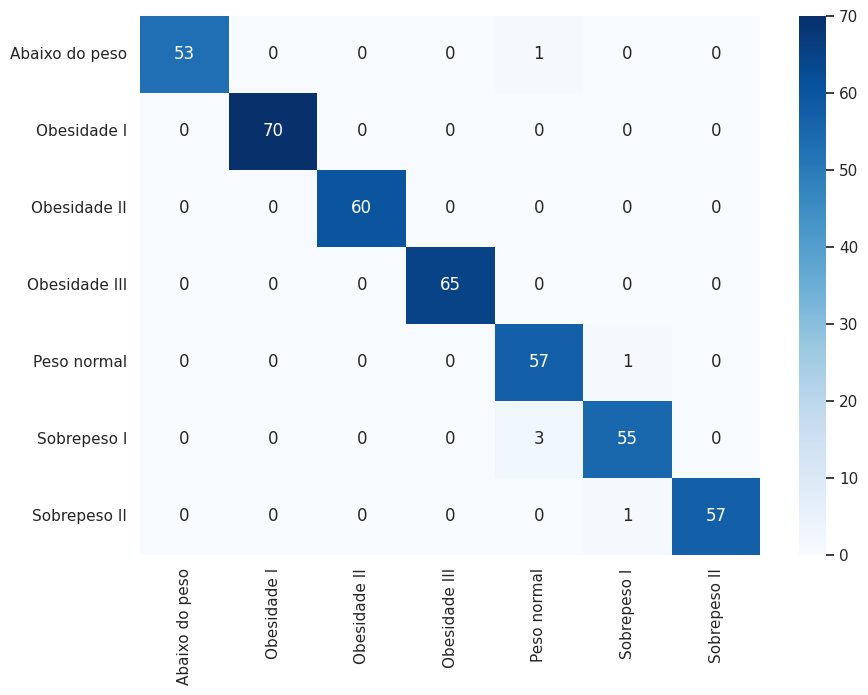

Iniciando download dos artefatos: Modelo, Base de Dados, App Streamlit e Requirements...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ==============================================================================
# 5. MODELAGEM PREDITIVA, AVALIAÇÃO E EXPORTAÇÃO + GERAÇÃO DO APP E REQUIREMENTS
# Treinamento do estimador, extração de métricas e deploy dos artefatos.
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import pandas as pd
import sklearn
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# --- GERAÇÃO DO ARQUIVO APP.PY PARA O STREAMLIT ---
with open('app.py', 'w', encoding='utf-8') as f:
    f.write("""import streamlit as st
import joblib
import pandas as pd

st.set_page_config(page_title="Diagnóstico de Peso Corporal", page_icon="🩺", layout="wide")
st.title("🩺 Diagnóstico de Peso Corporal")

@st.cache_resource
def load_model():
    return joblib.load('modelo_obesidade_rf.pkl')

model = load_model()

st.subheader("Preencha os dados do paciente:")

col1, col2, col3 = st.columns(3)

with col1:
    genero = st.selectbox("Gênero", ["Masculino", "Feminino"])
    idade = st.number_input("Idade", min_value=1, max_value=100, value=25)
    altura = st.number_input("Altura (m)", min_value=1.0, max_value=2.5, value=1.70, step=0.01)
    peso = st.number_input("Peso (kg)", min_value=10.0, max_value=250.0, value=70.0, step=0.1)
    familia = st.selectbox("Histórico Familiar de Obesidade?", ["Sim", "Nao"])
    fumante = st.selectbox("Fumante?", ["Sim", "Nao"])

with col2:
    calorico = st.selectbox("Consumo frequente de alimentos muito calóricos?", ["Sim", "Nao"])
    vegetais = st.selectbox("Frequência de consumo de vegetais", ["Raramente", "As vezes", "Sempre"])
    refeicoes = st.selectbox("Número de refeições principais por dia", ["1 refeicao", "2 refeicoes", "3 refeicoes", "4 ou mais"])
    lanches = st.selectbox("Consumo de lanches (entre refeições)", ["Nao", "As vezes", "Frequentemente", "Sempre"])
    agua = st.selectbox("Consumo diário de água", ["< 1 L/dia", "1-2 L/dia", "> 2 L/dia"])

with col3:
    monitora_cal = st.selectbox("Monitora ingestão calórica?", ["Sim", "Nao"])
    ativ_fisica = st.selectbox("Atividade física semanal", ["Nenhuma", "1-2 dias/sem", "3-4 dias/sem", "5+ dias/sem"])
    telas = st.selectbox("Tempo diário de tela", ["0-2 h/dia", "3-5 h/dia", "> 5 h/dia"])
    alcool = st.selectbox("Consumo de álcool", ["Nao", "As vezes", "Frequentemente", "Sempre"])
    transporte = st.selectbox("Transporte habitual", ["Carro", "Moto", "Bicicleta", "Transporte Publico", "A pe"])

st.markdown("---")

if st.button("Realizar Previsão"):
    imc = round(peso / (altura ** 2), 2)

    dados_entrada = {
        'Genero': genero, 'Idade': idade, 'Altura': altura, 'Peso': peso,
        'Historico_Familiar': familia, 'Consumo_Alta_Caloria': calorico,
        'Consumo_Vegetais': vegetais, 'Refeicoes_Dia': refeicoes,
        'Consumo_Entre_Refeicoes': lanches, 'Fumante': fumante,
        'Consumo_Agua': agua, 'Monitora_Calorias': monitora_cal,
        'Frequencia_Ativ_Fisica': ativ_fisica, 'Tempo_Telas': telas,
        'Consumo_Alcool': alcool, 'Meio_Transporte': transporte, 'IMC': imc
    }

    df_input = pd.DataFrame([dados_entrada])

    try:
        resultado = model.predict(df_input)[0]
        st.success(f"**Resultado do Diagnóstico:** {resultado}")
    except Exception as e:
        st.error(f"Erro ao processar a predição: {e}")
""")

# --- GERAÇÃO DO ARQUIVO REQUIREMENTS.TXT COM VERSÕES DO COLAB ---
with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write("streamlit\n")
    f.write(f"pandas=={pd.__version__}\n")
    f.write(f"scikit-learn=={sklearn.__version__}\n")
    f.write(f"joblib=={joblib.__version__}\n")

# 5.1. Construção do Pipeline Final
pipeline_rf = Pipeline([
    ('preprocessor', preprocessador),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1))
])

# 5.2. Treinamento do Modelo
print("Processando treinamento do modelo Random Forest...")
pipeline_rf.fit(X_train, y_train)

# 5.3. Previsões e Métricas
y_pred = pipeline_rf.predict(X_test)
print(f"ACURÁCIA GLOBAL: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 5.4. Visualização (Matriz de Confusão)
plt.figure(figsize=(10, 7))
labels_classes = pipeline_rf.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_classes, yticklabels=labels_classes)
plt.show()

# 5.5. Serialização do Modelo
nome_arquivo_modelo = 'modelo_obesidade_rf.pkl'
joblib.dump(pipeline_rf, nome_arquivo_modelo)

# 5.6. Exportação da Base de Dados Tratada (Padrão BR para Data Viz)
nome_arquivo_csv = 'obesity_tratada_grupo45.csv'
df.to_csv(nome_arquivo_csv, index=False, sep=';', decimal=',', encoding='utf-8-sig')

# 5.7. Download automático dos QUATRO arquivos
print("Iniciando download dos artefatos: Modelo, Base de Dados, App Streamlit e Requirements...")
files.download(nome_arquivo_modelo)
files.download(nome_arquivo_csv)
files.download('app.py')
files.download('requirements.txt')